<a href="https://colab.research.google.com/github/Mufliha-Hafsyah/PCVK_Ganjil_2026/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAPORAN PRAKTIKUM <br> Pengolahan Citra dan Visi Komputer (PCVK)

**Nama** : Mufliha Hafsyah Shahieza <br>
**NIM** : 244107020147 <br>
**Kelas** : TI-3G

---

## Modul 2 – Representasi dan Karakteristik Citra Digital

1. Membuat koneksi antara Colab dengan Google Drive agar bisa
mengakses file di dalamnya.

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#Mengakses gambar dengan fungsi upload file

from google.colab import files
uploaded = files.upload()


Saving ktm.jpeg to ktm.jpeg


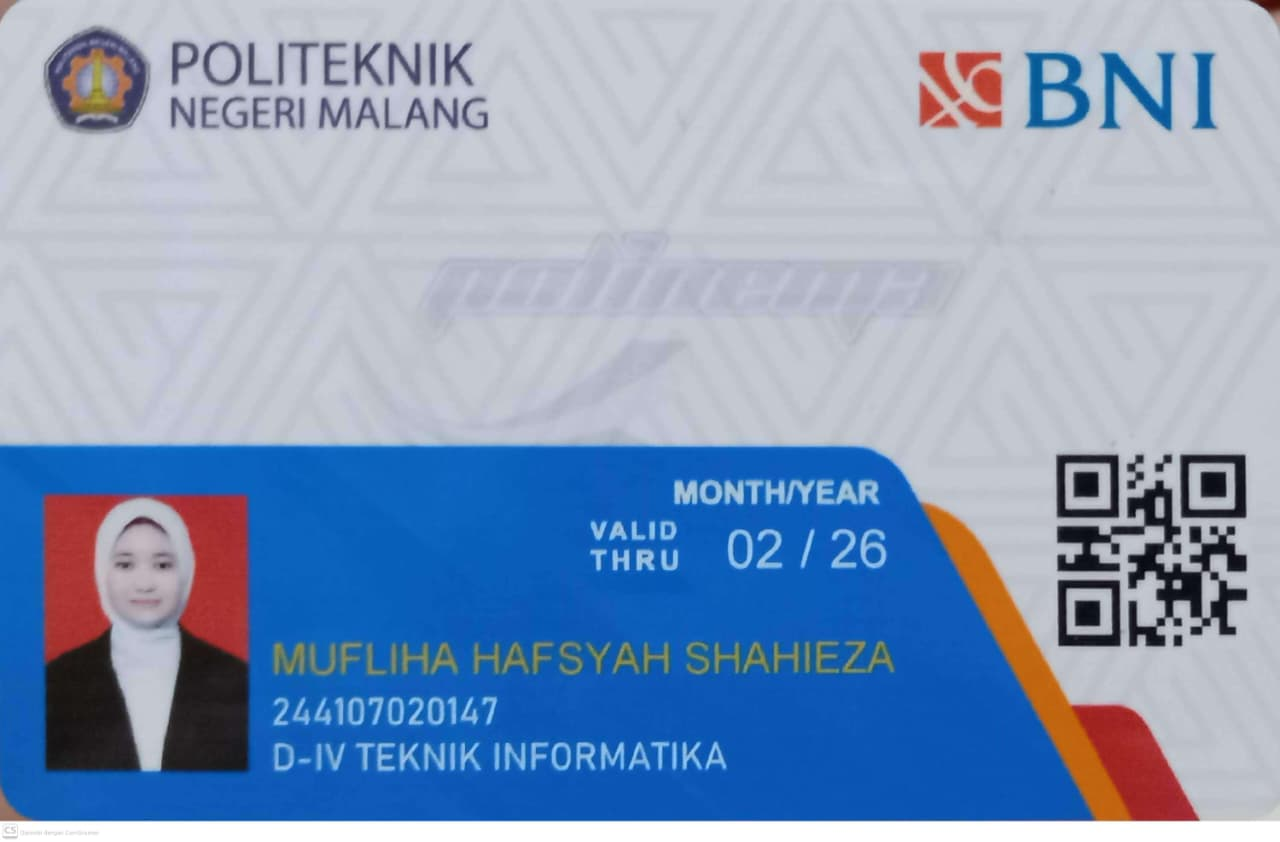

Resolusi gambar:  1280 x 842


In [5]:
#Untuk menampilkan gambar

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktm.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

2. Menampilkan Gambar

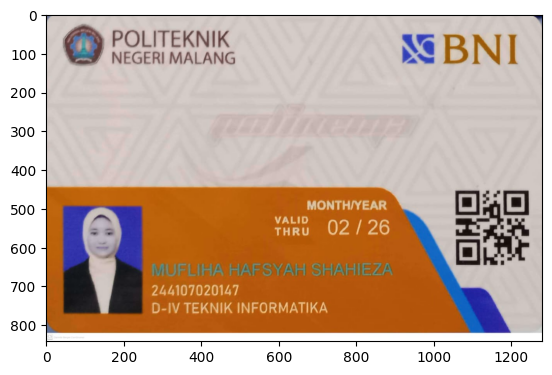

In [8]:
img = cv.imread('ktm.jpeg')
plt.imshow(img) #format warna BGR

Jika menginginkan format warna RGB dapat dilakukan dengan beberapa cara:

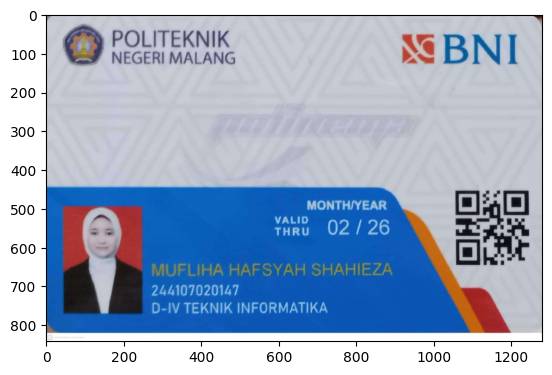

In [9]:
img = cv.imread('ktm.jpeg')
img2= cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img2)

Atau langsung digabung:

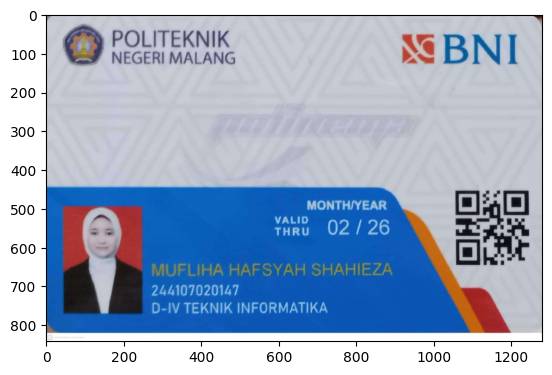

In [10]:
img = cv.imread('ktm.jpeg')
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.show()

3. Menampilkan Citra Grayscale

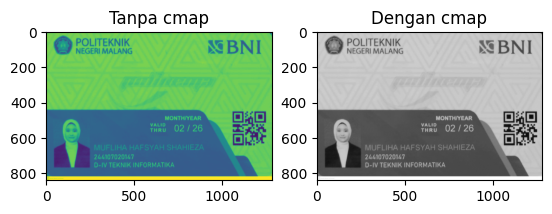

In [11]:
img_gray = cv.imread('ktm.jpeg', cv.IMREAD_GRAYSCALE)

#Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

#Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

Jika ingin mengganti warna yang lain, tinggal mengganti cmap sesuai keinginan, contohnya untuk ditampilkan colormap dengan warna ‘magma’

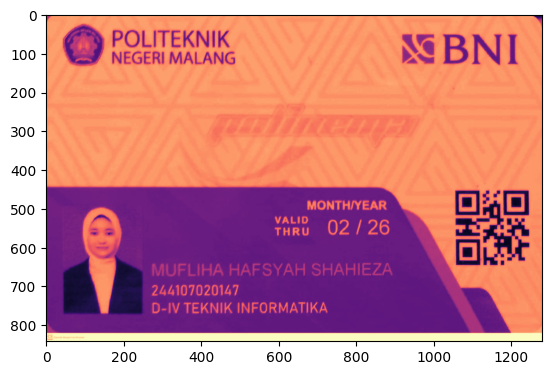

In [13]:
plt.imshow(img_gray, cmap='magma')

4. Melakukan resizing

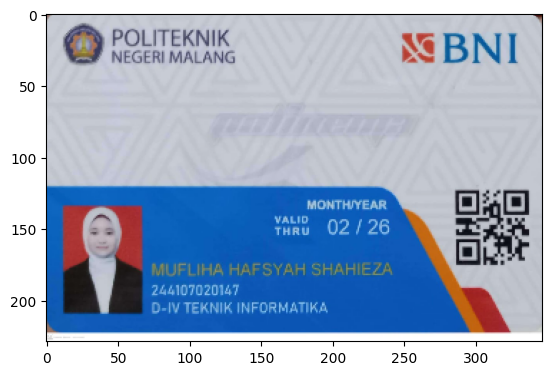

In [14]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

5. Melakukan Flipping

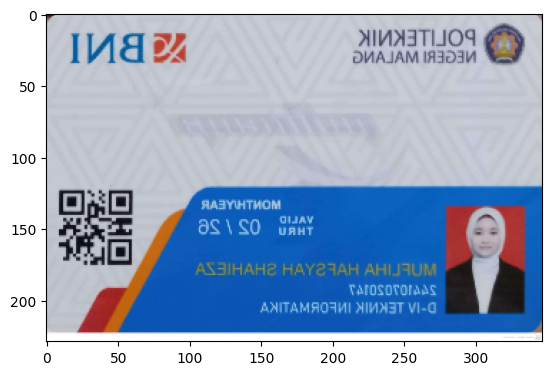

In [15]:
imgFlip = cv.flip(img_output,1)
plt.imshow(imgFlip)

Sedangkan untuk memperbesar ukuran canvas yang lebih besar dengan posisi gambar terbalik:

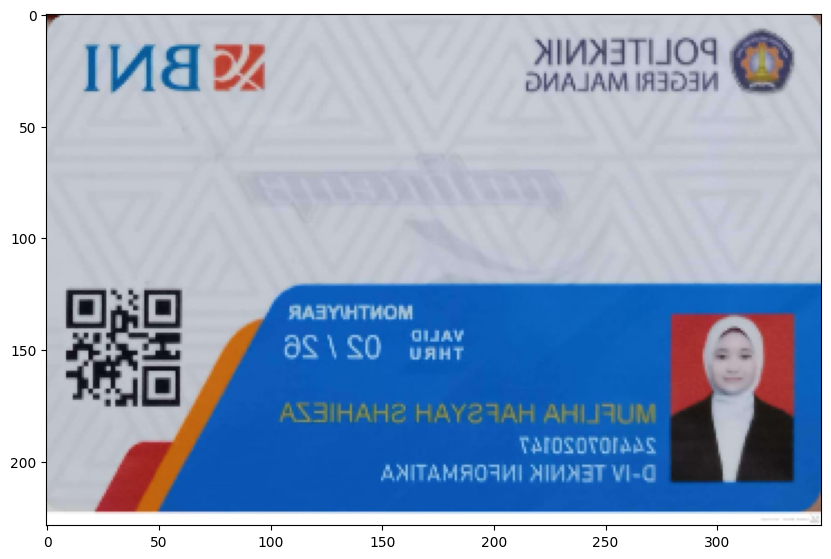

In [16]:
imgFlip = cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan
black image dengan tipe data int16.

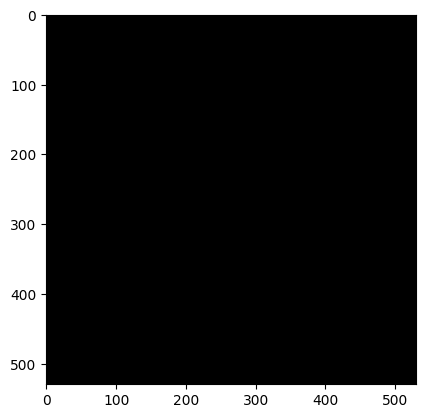

In [9]:
black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

Kemudian menambahkan bentuk persegi panjang sesuai koordinat pt1 dan pt2

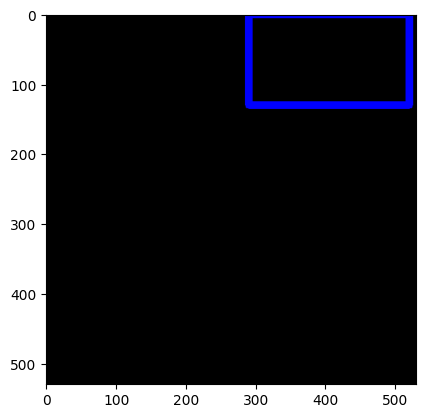

In [11]:
#Perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

Selanjutnya ditambah menambahkan bentuk persegi sesuai koordinat pt1 dan
pt2 yang tertulis pada kode program.

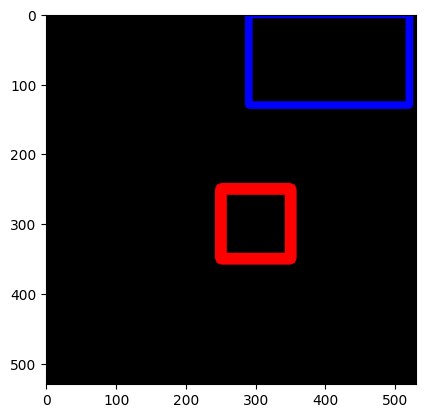

In [12]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

Tahap selanjutnya ditambah menambahkan bentuk lingkaran sesuai radius
yang tertulis pada kode program.

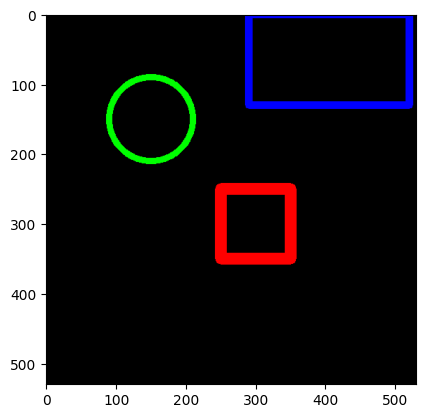

In [14]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

Kemudian dilakukan penambahan lingkaran berwarna dan garis sesuai
koordinat pt1 dan pt2 sebagai berikut.

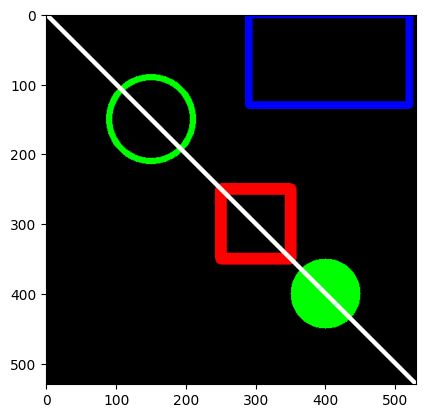

In [15]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

Penambahan text dengan font yang telah tertulis dengan ukuran yang sudah
ditentukan.

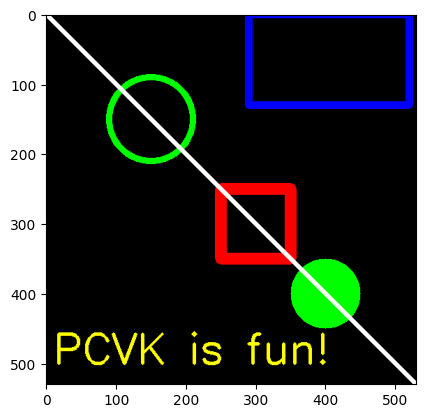

In [17]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,
          color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

Pembuatan black image kembali dilakukan dengan tipe data int32

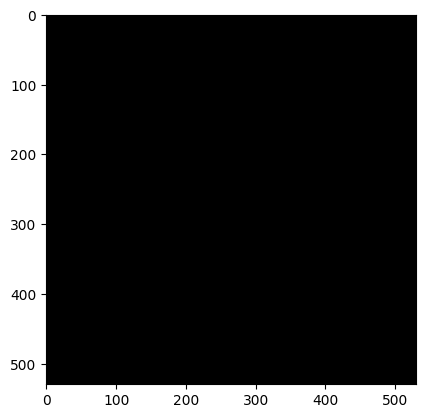

In [18]:
black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

Berikut adalah kode program untuk inisialisasi NumPy array dengan tipe data
int32

In [19]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

Array tersebut kemudian di reshape sebagai berikut

In [20]:
pts = vertices.reshape((-1,1,2)) #nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channe; yg mewakili R, G, dan B
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

Penambahan polyline pada black image kedua yang telah dibuat.

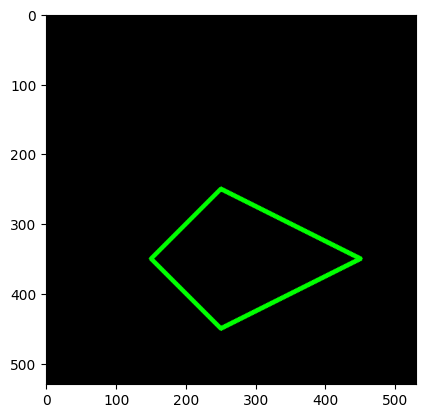

In [22]:
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

### PERTANYAAN PRAKTIKUM

1. **Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.**<br>
Jawaban:

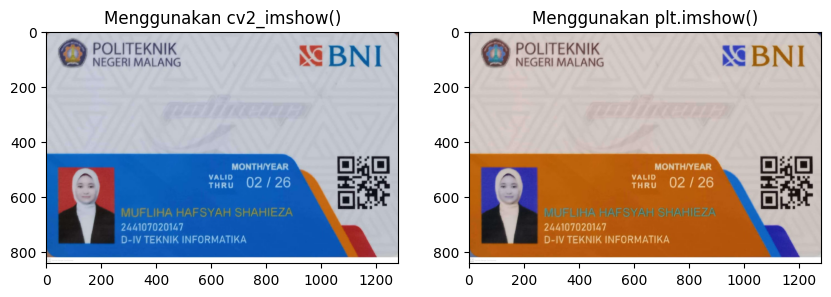

Nilai piksel (0,0) pada array 'img' asli (BGR): [110 121 159]
Nilai piksel (0,0) pada array 'img_rgb' (RGB) : [159 121 110]


In [8]:
img = cv.imread('ktm.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Menggunakan cv2_imshow()')

plt.subplot(1,2,2)
plt.imshow(img)
plt.title('Menggunakan plt.imshow()')

plt.show()

print("Nilai piksel (0,0) pada array 'img' asli (BGR):", img[0,0])
print("Nilai piksel (0,0) pada array 'img_rgb' (RGB) :", img_rgb[0,0])

Kedua tampilan menyajikan citra yang sama, namun dengan urutan saluran (channel) warna yang berbeda. Nilai piksel pada koordinat (0,0) untuk img dan img_rgb menunjukkan urutan elemen yang berkebalikan, saluran pertama dan ketiga saling bertukar posisi—yang membuktikan bahwa informasi datanya identik meski strukturnya berbeda.<br>

Fungsi cv2_imshow() menginterpretasikan matriks sesuai dengan format aslinya (BGR) sehingga warna citra dapat ditampilkan dengan benar. Sebaliknya, plt.imshow() secara bawaan mengasumsikan input berformat RGB. Apabila matriks BGR dimasukkan tanpa konversi terlebih dahulu, saluran merah dan biru akan mengalami pergeseran interpretasi, sehingga menghasilkan visualisasi warna yang tidak sesuai dengan kondisi aslinya.

2. **Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.**<br>
Jawaban:

Kanvas int16 = dtype: int16 , min: 0 , max: 0 , nbytes: 960000
Kanvas int32 = dtype: int32 , min: 0 , max: 0 , nbytes: 1920000


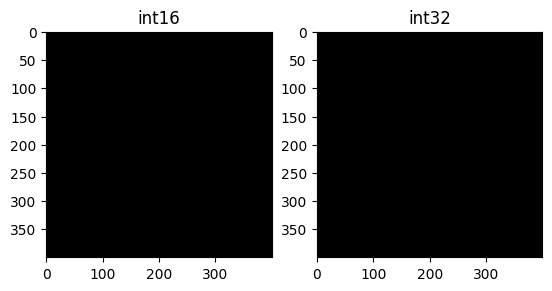

In [10]:
canvas_int16 = np.zeros((400, 400, 3), dtype=np.int16)
canvas_int32 = np.zeros((400, 400, 3), dtype=np.int32)

print("Kanvas int16 = dtype:", canvas_int16.dtype, ", min:", canvas_int16.min(),
      ", max:", canvas_int16.max(), ", nbytes:", canvas_int16.nbytes)
print("Kanvas int32 = dtype:", canvas_int32.dtype, ", min:", canvas_int32.min(),
      ", max:", canvas_int32.max(), ", nbytes:", canvas_int32.nbytes)

plt.subplot(1,2,1); plt.imshow(canvas_int16.astype(np.uint8)); plt.title('int16')
plt.subplot(1,2,2); plt.imshow(canvas_int32.astype(np.uint8)); plt.title('int32')
plt.show()

Berdasarkan hasil keluaran program, nilai minimum (min()) dan maksimum (max()) pada kedua kanvas bernilai 0 karena diinisialisasi menggunakan np.zeros. Oleh karena itu, kedua kanvas menghasilkan tampilan visual yang identik, yaitu berupa bidang hitam polos.<br>

Meskipun demikian, terdapat perbedaan signifikan pada alokasi memori (nbytes). Kanvas dengan tipe data int32 mengonsumsi memori dua kali lebih besar dibandingkan int16. Hal ini disebabkan oleh penggunaan memori sebesar 2 byte per elemen pada int16 (dengan rentang nilai −32.768 hingga 32.767), sedangkan int32 memerlukan 4 byte per elemen untuk mengakomodasi jangkauan nilai yang lebih luas (−2.147.483.648 hingga 2.147.483.647). Dengan demikian, ukuran memori yang dibutuhkan bergantung pada batas kapasitas tipe data (dtype) yang digunakan, bukan berdasarkan nilai aktual yang tersimpan.

3. **Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab**<br>
Jawaban:

In [11]:
try:
    cv.imshow('test', img)
except Exception as e:
    print("Error saat mencoba cv2.imshow() bawaan OpenCV di Colab:")
    print(type(e).__name__, "-", e)

Error saat mencoba cv2.imshow() bawaan OpenCV di Colab:
DisabledFunctionError - cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow



Fungsi bawaan cv2.imshow() pada OpenCV dirancang untuk menampilkan citra melalui jendela Graphical User Interface (GUI) pada sistem operasi lokal. Lingkungan Google Colab beroperasi pada server headless yang tidak dilengkapi antarmuka desktop, sehingga pemanggilan fungsi tersebut secara langsung akan menghasilkan kesalahan eksekusi (error).<br>

Untuk mengatasi keterbatasan tersebut, modul google.colab.patches.cv2_imshow diimpor sebagai fungsi alternatif. Fungsi pengganti ini memungkinkan citra ditayangkan secara langsung sebagai keluaran pada sel (cell output) notebook dalam bentuk gambar statis tanpa memerlukan antarmuka GUI terpisah.

4. **Citra yang dibaca dengan `skimage.io.imread()` ditampilkan berdampingan dengan hasil `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.**<br>
Jawaban:

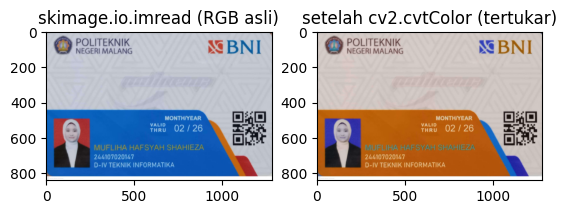

Piksel (0,0) - skimage.io.imread (asli)  : [159 121 110]
Piksel (0,0) - setelah cv2.cvtColor      : [110 121 159]


In [13]:
from skimage import io

img_skimage = io.imread('ktm.jpeg')                       # skimage sudah membaca dalam urutan RGB
img_swapped = cv.cvtColor(img_skimage, cv.COLOR_BGR2RGB)   # cvtColor ini keliru diterapkan pada citra yg sudah RGB

plt.subplot(1,2,1); plt.imshow(img_skimage); plt.title('skimage.io.imread (RGB asli)')
plt.subplot(1,2,2); plt.imshow(img_swapped); plt.title('setelah cv2.cvtColor (tertukar)')
plt.show()

print("Piksel (0,0) - skimage.io.imread (asli)  :", img_skimage[0,0])
print("Piksel (0,0) - setelah cv2.cvtColor      :", img_swapped[0,0])

Fungsi skimage.io.imread() secara bawaan membaca citra dalam format saluran (channel) warna RGB, sehingga visualisasi yang dihasilkan langsung menampilkan warna asli citra.<br>

Penerapan fungsi cv2.cvtColor(img, cv2.COLOR_BGR2RGB) pada citra yang sudah berformat RGB justru menyebabkan rotasi ulang pada susunan salurannya. Hal ini terjadi karena fungsi tersebut mengasumsikan matriks masukan berformat BGR. Akibatnya, saluran merah dan biru saling bertukar posisi. Ketidaksesuaian ini terkonfirmasi dari nilai piksel pada koordinat (0,0), di mana indeks saluran pertama dan ketiga (indeks 0 dan 2) pada array img_swapped merupakan kebalikan dari img_skimage, nilai yang awalnya menempati saluran merah berpindah ke saluran biru, dan sebaliknya.

5. **Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai `img.shape` ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.**<br>
Jawaban:

Shape SEBELUM ditampilkan dengan figsize besar: (842, 1280, 3)


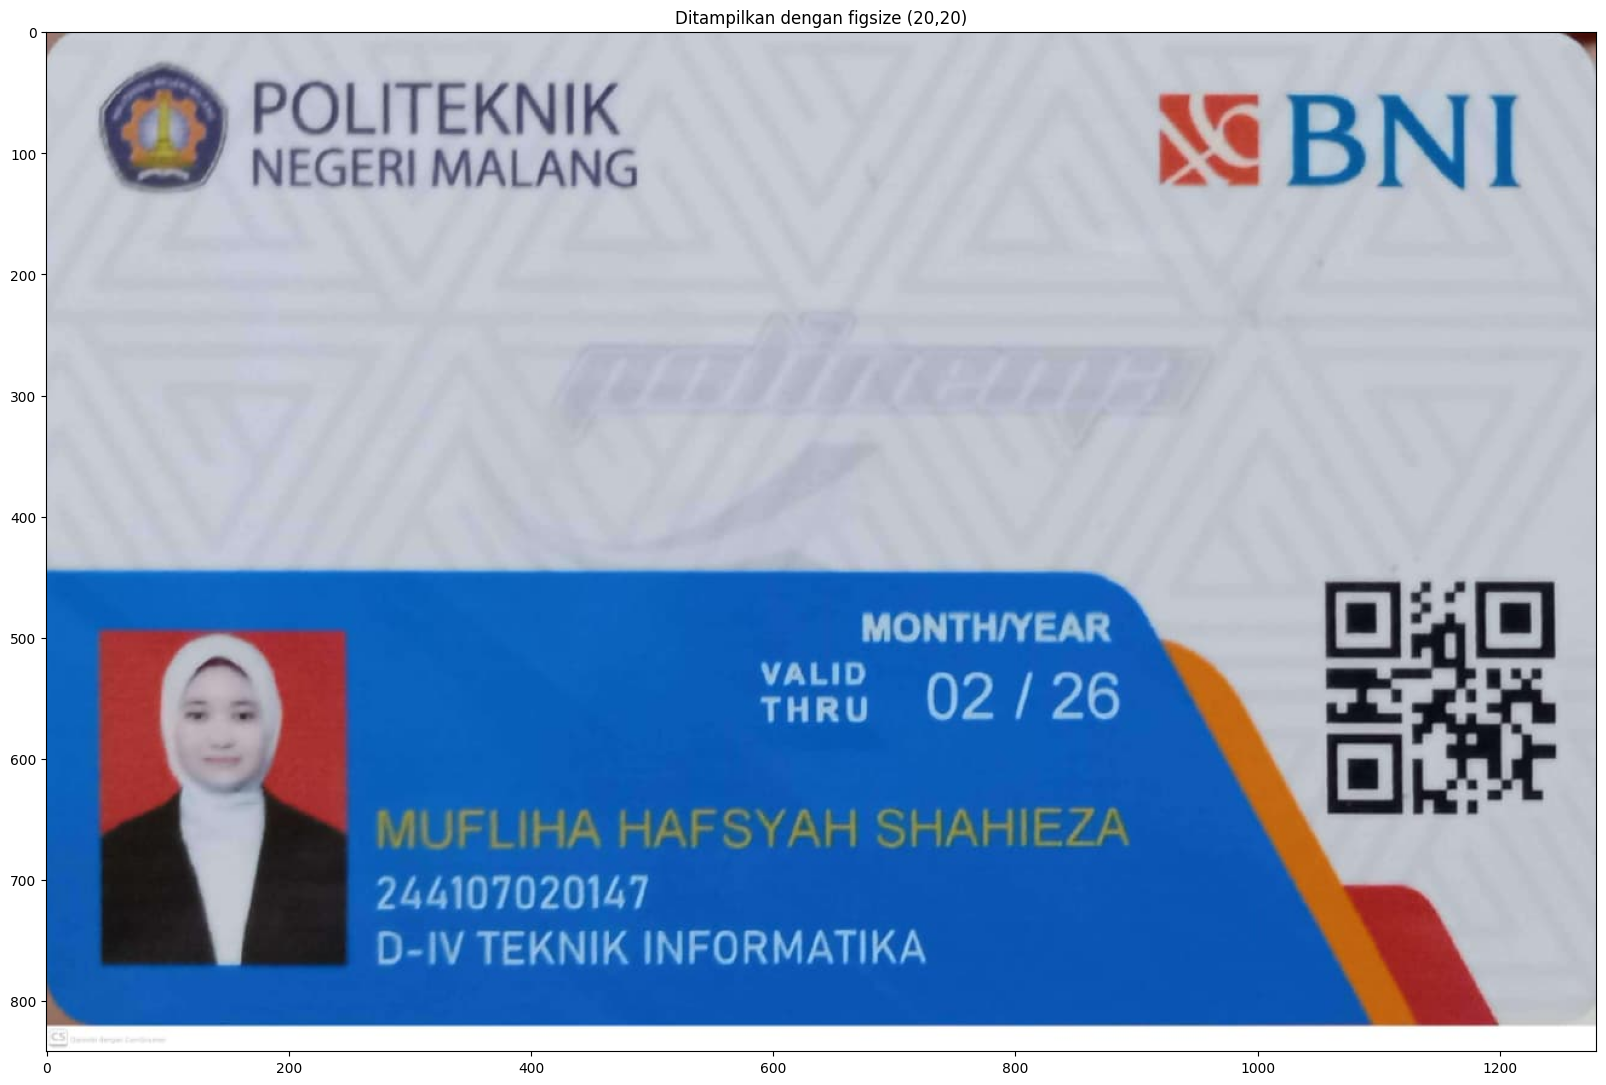

Shape SETELAH ditampilkan dengan figsize besar: (842, 1280, 3)


In [14]:
print("Shape sebelum ditampilkan dengan figsize besar:", img.shape)

plt.figure(figsize=(20, 20))   # ukuran kanvas tampilan dibuat jauh lebih besar
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Ditampilkan dengan figsize (20,20)')
plt.show()

print("Shape setelah ditampilkan dengan figsize besar:", img.shape)

Berdasarkan hasil keluaran program, dimensi matriks pada img.shape tidak mengalami perubahan sebelum maupun sesudah penerapan parameter figsize.<br>

Hal ini terjadi karena penentuan figsize pada fungsi plt.figure() hanya memengaruhi ukuran tampilan visual kanvas (dalam satuan inci) pada layar keluaran, tanpa mengubah struktur data matriks citra itu sendiri. Kondisi ini berbeda secara mendasar dengan operasi perubahan ukuran citra (seperti cv2.resize()), yang secara langsung mengubah jumlah piksel sehingga memicu perubahan pada img.shape. Ringkasnya, figsize mengatur skala visualisasi, sedangkan cv2.resize() mengubah dimensi data matriks.

### TUGAS PRAKTIKUM - PENERAPAN

1. **Tampilkan citra hanya pada kombinasi kanal **Merah-Biru** dan kanal **Hijau-Biru** saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.** <br>
Jawaban:<br>


In [86]:
from google.colab import files
uploaded = files.upload()

Saving fanny.jpg to fanny.jpg


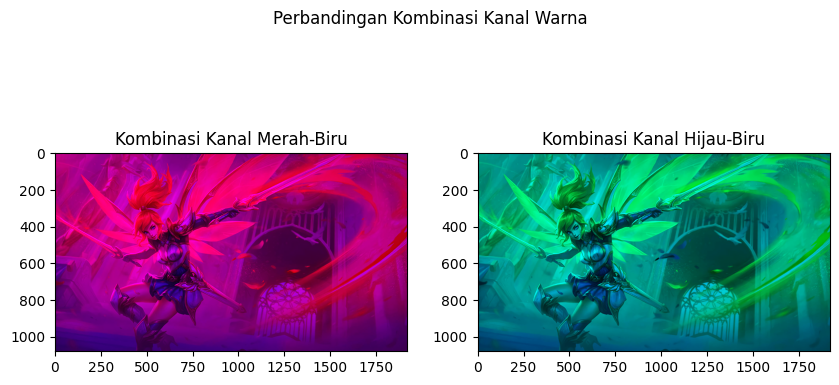

In [87]:
img = cv.imread('fanny.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Kombinasi Merah-Biru: kanal Hijau (indeks 1) dinolkan
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# Kombinasi Hijau-Biru: kanal Merah (indeks 0) dinolkan
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title('Kombinasi Kanal Merah-Biru')

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title('Kombinasi Kanal Hijau-Biru')

plt.suptitle('Perbandingan Kombinasi Kanal Warna')
plt.show()

2. **Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan
keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi
label.**<br>
Jawaban:

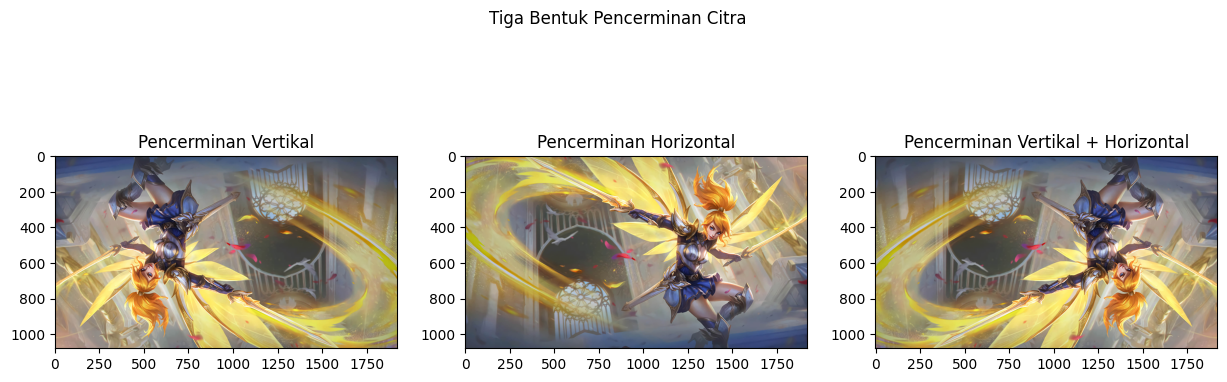

In [88]:
img_flip_v = cv.flip(img_rgb, 0)
img_flip_h = cv.flip(img_rgb, 1)
img_flip_vh = cv.flip(img_rgb, -1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_flip_v)
plt.title('Pencerminan Vertikal')

plt.subplot(1, 3, 2)
plt.imshow(img_flip_h)
plt.title('Pencerminan Horizontal')

plt.subplot(1, 3, 3)
plt.imshow(img_flip_vh)
plt.title('Pencerminan Vertikal + Horizontal')

plt.suptitle('Tiga Bentuk Pencerminan Citra')
plt.show()

3. **Gambarkan sebuah *rectangle* dan sebuah *circle* pada bagian wajah/badan dari foto aktivitas pribadi (bukan pasfoto), lalu tambahkan teks berisi nama dengan pilihan font, ukuran, dan warna sendiri.**<br>
Jawaban:

In [17]:
# Upload foto aktivitas pribadi (bukan pasfoto)
from google.colab import files
uploaded_aktivitas = files.upload()

Saving activity.jpeg to activity.jpeg


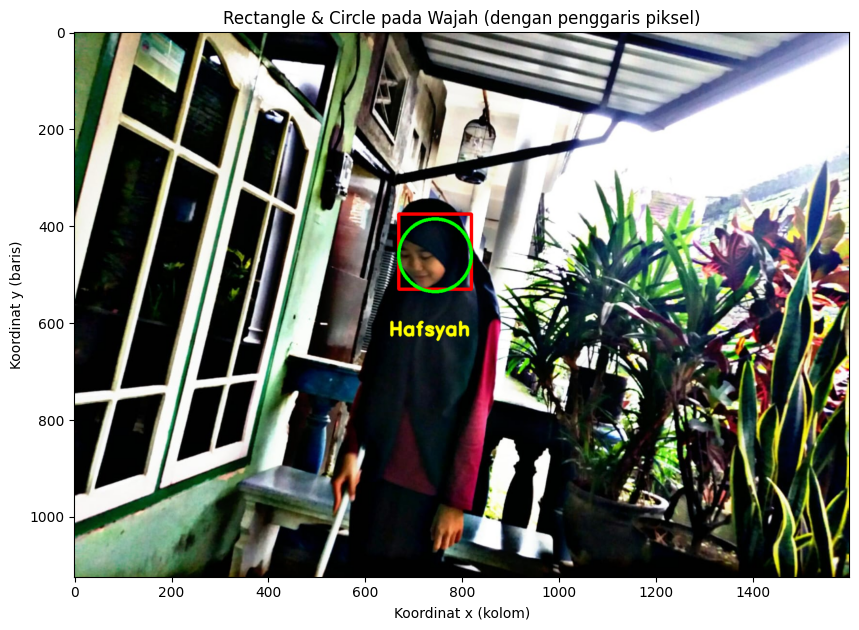

In [37]:
img = cv.imread('activity.jpeg')
img_draw = img.copy()

pt1 = (670, 375)
pt2 = (820, 530)
cv.rectangle(img_draw, pt1, pt2, color=(0, 0, 255), thickness=6)

center = (745, 460)
radius = 75
cv.circle(img_draw, center, radius, color=(0, 255, 0), thickness=6)

font = cv.FONT_HERSHEY_DUPLEX
cv.putText(img_draw, "Hafsyah",
           org=(pt1[0] - 20, pt1[1] - (-250)),
           fontFace=font, fontScale=1.3,
           color=(0, 255, 255),
           thickness=3, lineType=cv.LINE_AA)
# Tampilan 2: plt.imshow sebagai kanvas berpenggaris (sumbu piksel x dan y)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_draw, cv.COLOR_BGR2RGB))   # tanpa cvtColor -> warna BGR, tapi sumbu koordinat piksel muncul
plt.title("Rectangle & Circle pada Wajah")
plt.xlabel("Koordinat x (kolom)")
plt.ylabel("Koordinat y (baris)")
plt.show()

### TUGAS PRAKTIKUM ANALISA
1. **Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.** <br>
Jawaban:<br>
- **Pertanyaan:** Apakah mengecilkan lalu membesarkan kembali citra ke ukuran semula mengubah rata-rata intensitas pikselnya?
- **Rancangan program:**


In [41]:
img = cv.imread('ktm.jpeg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
h, w = img_gray.shape[:2]

# rata-rata intensitas citra asli
mean_asli = img_gray.mean()

# kecilkan lalu besarkan lagi ke ukuran semula
kecil = cv.resize(img_gray, (w//4, h//4), interpolation=cv.INTER_AREA)
besar_lagi = cv.resize(kecil, (w, h), interpolation=cv.INTER_CUBIC)
mean_setelah = besar_lagi.mean()

print("Rata-rata intensitas citra asli    :", mean_asli)
print("Rata-rata intensitas setelah resize:", mean_setelah)
print("Selisih:", abs(mean_asli - mean_setelah))

Rata-rata intensitas citra asli   : 152.88438706205463
Rata-rata intensitas setelah resize: 152.84848482036818
Selisih: 0.035902241686443404


**Data hasil:**
- Rata-rata intensitas citra asli    : 152.88438706205463
- Rata-rata intensitas setelah resize: 152.84848482036818
- Selisih: 0.035902241686443404

**Kesimpulan:** <br>

Berdasarkan data hasil di atas, rata-rata intensitas citra asli (152.884) dan rata-rata intensitas citra setelah dikecilkan lalu dibesarkan kembali ke ukuran semula (152.848) hanya berselisih sebesar **0.036**, atau sekitar **0.023%** dari nilai rata-rata asli.

Ini menunjukkan bahwa proses downscaling lalu upscaling tidak mengubah rata-rata intensitas citra secara signifikan. Hal ini sesuai dengan penjelasan pada teori modul bahwa proses interpolasi (baik `INTER_AREA` saat mengecilkan maupun `INTER_CUBIC` saat membesarkan) hanya memperkirakan nilai piksel baru dari piksel-piksel tetangganya, bukan menciptakan informasi baru. Operasi resize pada dasarnya melakukan semacam rata-rata/interpolasi lokal terhadap nilai piksel di sekitarnya, sehingga secara statistik distribusi intensitas keseluruhan citra cenderung tetap terjaga meskipun detail-detail halus (piksel per piksel) bisa saja berubah atau hilang.

Dengan kata lain, meskipun resolusi spasial (jumlah piksel) citra sempat berubah dan detail tajam pada citra kemungkinan besar sedikit kabur (blur) akibat interpolasi, informasi global seperti rata-rata kecerahan citra tetap konsisten. Ini membuktikan bahwa resize bukan proses yang "acak" secara nilai, ia tetap mempertahankan karakteristik keseluruhan citra, walau bukan berarti citra hasil resize identik dengan citra aslinya secara piksel per piksel.


### TUGAS PRAKTIKUM APLIKASI
**Studi Kasus 1:** <br>
Panitia sebuah kegiatan perlu membubuhkan label identitas pada
ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel,
sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada
semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua
citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama. Silakan melakukan akuisisi data sendiri, setiap anak
harus menggunakan image yang berbeda-beda

In [67]:
from google.colab import files
uploaded = files.upload()

Saving zetian.jpg to zetian.jpg
Saving rafaela.jpg to rafaela.jpg


In [68]:
import os
print(os.listdir())

['.config', 'activity.jpeg', 'ktm.jpeg', 'nana.jpg', 'joy.jpg', 'rafaela.jpg', 'zetian.jpg', 'joy (1).jpg', 'drive', 'sample_data']


In [70]:
def beri_label(path_gambar, teks):
    img = cv.imread(path_gambar)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    tinggi_bar = h // 12
    font_scale = w / 700
    tebal_teks = max(1, w // 300)

    img_out = img.copy()
    cv.rectangle(img_out, (0, h - tinggi_bar), (w, h), (0, 0, 0), thickness=-1)

    font = cv.FONT_HERSHEY_SIMPLEX
    posisi_teks = (w // 40, h - tinggi_bar // 3)
    cv.putText(img_out, teks, posisi_teks, font, font_scale,
               (255, 255, 255), tebal_teks, lineType=cv.LINE_AA)

    return img, img_out, tinggi_bar

In [71]:
asli1, hasil1, bar1 = beri_label('zetian.jpg', 'Dokumentasi PCVK - 2026')
asli2, hasil2, bar2 = beri_label('rafaela.jpg', 'Dokumentasi PCVK - 2026')

print('zetian.jpg ->', asli1.shape[1], 'x', asli1.shape[0], 'px, bar =', bar1)
print('rafaela.jpg ->', asli2.shape[1], 'x', asli2.shape[0], 'px, bar =', bar2)

zetian.jpg -> 1920 x 1080 px, bar = 90
rafaela.jpg -> 3840 x 2160 px, bar = 180


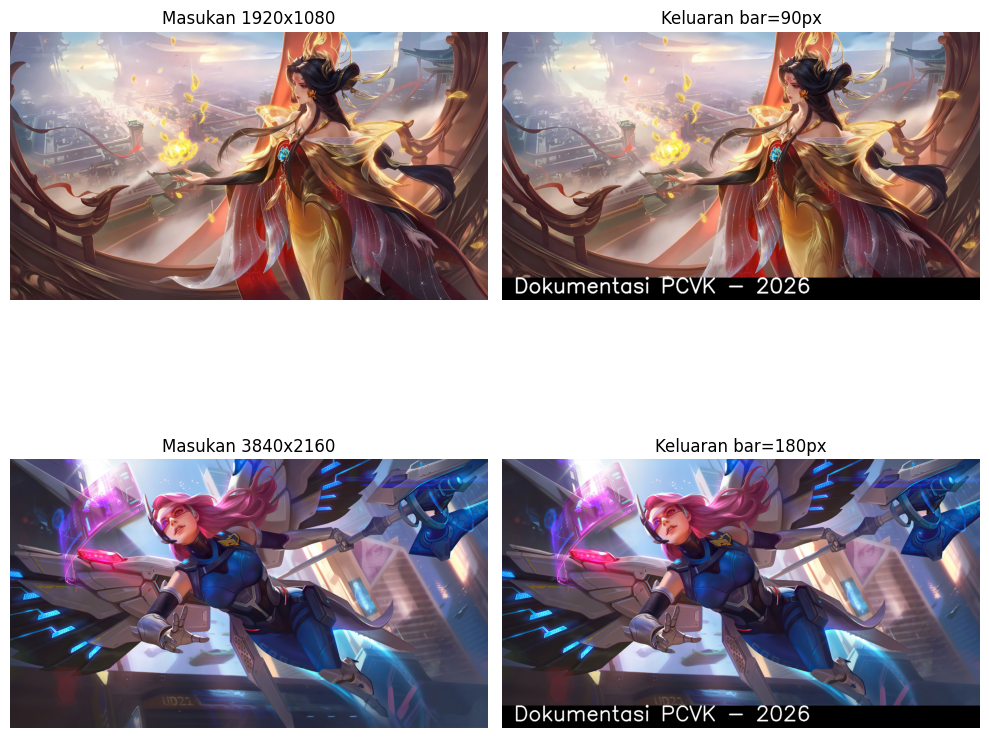

In [73]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0,0].imshow(asli1); ax[0,0].set_title(f'Masukan {asli1.shape[1]}x{asli1.shape[0]}'); ax[0,0].axis('off')
ax[0,1].imshow(hasil1); ax[0,1].set_title(f'Keluaran bar={bar1}px'); ax[0,1].axis('off')
ax[1,0].imshow(asli2); ax[1,0].set_title(f'Masukan {asli2.shape[1]}x{asli2.shape[0]}'); ax[1,0].axis('off')
ax[1,1].imshow(hasil2); ax[1,1].set_title(f'Keluaran bar={bar2}px'); ax[1,1].axis('off')
plt.tight_layout()
plt.show()

**Studi Kasus 2:** <br>
Marketplace seperti Tokopedia dan Shopee menampilkan foto
produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau
lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja.
Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail
persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna.
Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas,
tambahkan logo nama toko berukuran proporsional pada gambar.

In [77]:
from google.colab import files
uploaded = files.upload()

Saving WDP.jpg to WDP.jpg


Ukuran gambar asli:
Lebar  : 1280 pixel
Tinggi : 720 pixel

Ukuran kanvas:
1280 x 1280 pixel

Ukuran foto setelah penyesuaian:
Lebar  : 1280 pixel
Tinggi : 720 pixel

Posisi foto pada kanvas:
X : 0
Y : 280


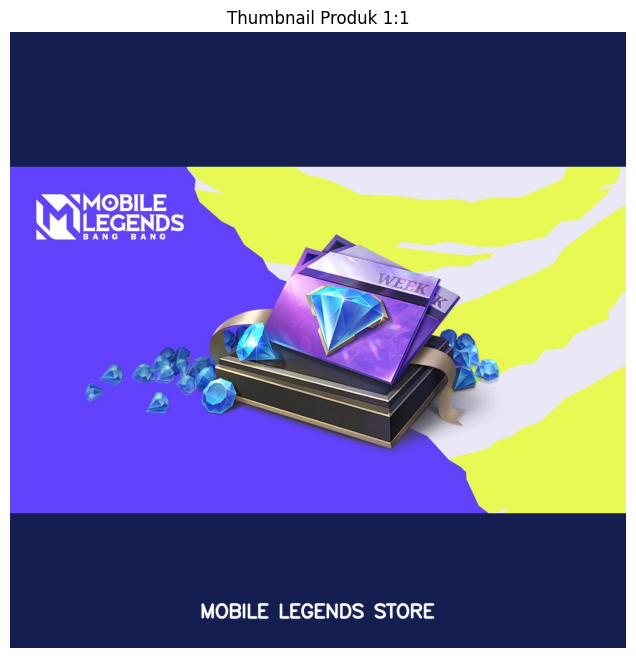

In [89]:
img = cv.imread('WDP.jpg')
h, w = img.shape[:2]

print("Ukuran gambar asli:")
print("Lebar  :", w, "pixel")
print("Tinggi :", h, "pixel")

canvas_size = max(h, w)
print("\nUkuran kanvas:")
print(canvas_size, "x", canvas_size, "pixel")

canvas = np.full(
    (canvas_size, canvas_size, 3),
    (80, 30, 20),
    dtype=np.uint8
)

scale = canvas_size / max(h, w)
new_w = int(w * scale)
new_h = int(h * scale)

print("\nUkuran foto setelah penyesuaian:")
print("Lebar  :", new_w, "pixel")
print("Tinggi :", new_h, "pixel")

img_resized = cv.resize(
    img,
    (new_w, new_h),
    interpolation=cv.INTER_AREA
)

x = (canvas_size - new_w) // 2
y = (canvas_size - new_h) // 2

print("\nPosisi foto pada kanvas:")
print("X :", x)
print("Y :", y)

canvas[y:y+new_h, x:x+new_w] = img_resized

nama_toko = "MOBILE LEGENDS STORE"
font = cv.FONT_HERSHEY_SIMPLEX
font_scale = canvas_size / 1000
thickness = max(1, int(canvas_size / 300))

(text_w, text_h), baseline = cv2.getTextSize(
    nama_toko,
    font,
    font_scale,
    thickness
)

text_x = (canvas_size - text_w) // 2
text_y = canvas_size - int(canvas_size * 0.05)

cv.putText(
    canvas,
    nama_toko,
    (text_x, text_y),
    font,
    font_scale,
    (255, 255, 255),
    thickness,
    cv.LINE_AA
)

plt.figure(figsize=(8, 8))
plt.imshow(
    cv.cvtColor(canvas, cv2.COLOR_BGR2RGB)
)
plt.title("Thumbnail Produk 1:1")
plt.axis("off")
plt.show()